# Phase 10 - Full Pipeline Assembly

**Goal**: Combine the best components from Phases 2-9 into a single, configurable RAG pipeline and validate it end-to-end.

## What this notebook does

1. **Component selection** - Justify each choice based on experimental evidence
2. **Pipeline assembly** - Build `RAGPipeline` from `configs/default.yaml`
3. **Full benchmark** - Run all 25 questions (not sampled like Phase 9)
4. **RAGAS evaluation** - Full end-to-end quality metrics
5. **Performance profiling** - Latency breakdown (retrieval vs generation)

## Winning configuration

| Component | Choice | Phase | Rationale |
|-----------|--------|-------|----------|
| Chunking | Recursive (1000/200) | 2 | Best balance of size and overlap |
| Embeddings | mxbai-embed-large | 3 | Highest retrieval MRR |
| Retrieval | Hybrid BM25+Dense (0.5/0.5) | 4 | Combines keyword + semantic matching |
| Reranking | Cross-encoder (ms-marco-MiniLM) | 7, 9 | +0.20 faithfulness, +0.19 relevancy |
| Query translation | Disabled | 5 | All techniques hurt MRR with Mistral 7B |
| Routing | Disabled | 6 | Corpus too small for routing benefit |
| Advanced patterns | Disabled | 8 | CRAG slow; Self-RAG/Adaptive fail with Mistral 7B |
| LLM | Mistral 7B (temp=0.0) | all | Local, deterministic |

## 0. Setup

In [1]:
import sys
import json
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=DeprecationWarning)

PROJECT_ROOT = Path(".").resolve().parent
sys.path.insert(0, str(PROJECT_ROOT))

from langchain_ollama import ChatOllama
from langchain_chroma import Chroma

# Paths
PERSIST_DIR  = PROJECT_ROOT / "vectorstore" / "chroma_db"
MODELS_YAML  = PROJECT_ROOT / "configs" / "models.yaml"
CONFIG_PATH  = PROJECT_ROOT / "configs" / "default.yaml"
GT_PATH      = PROJECT_ROOT / "data" / "evaluation" / "ground_truth.json"
RESULTS_DIR  = PROJECT_ROOT / "results"
RESULTS_PATH = RESULTS_DIR / "full_pipeline.json"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Models
LLM_MODEL = "mistral:7b"

print("Setup complete.")
print(f"  Project root : {PROJECT_ROOT}")
print(f"  Config       : {CONFIG_PATH}")
print(f"  Chroma DB    : {PERSIST_DIR}")

d:\Astyan\rag-exploration\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Setup complete.
  Project root : D:\Astyan\rag-exploration
  Config       : D:\Astyan\rag-exploration\configs\default.yaml
  Chroma DB    : D:\Astyan\rag-exploration\vectorstore\chroma_db


In [2]:
from src.embeddings.models import create_from_registry

# Initialize models - same pattern as notebooks 04-09
embeddings, emb_info = create_from_registry("mxbai_large", config_path=MODELS_YAML)
llm = ChatOllama(model=LLM_MODEL, temperature=0.0)

EMBED_MODEL = emb_info.name

# Warmup
_ = llm.invoke("Hi")
print(f"LLM ready : {LLM_MODEL}")
print(f"Embeddings: {EMBED_MODEL}")

LLM ready : mistral:7b
Embeddings: mxbai_large


## 1. Pipeline Configuration

Load the production config from `configs/default.yaml` and display the key parameters.

In [3]:
from src.config import load_config

config = load_config(str(CONFIG_PATH))

print("Pipeline configuration:")
print(f"  LLM          : {config['llm']['model']} (temp={config['llm']['temperature']})")
print(f"  Embeddings   : {config['embeddings']['model']}")
print(f"  Chunking     : {config['chunking']['strategy']} ({config['chunking']['chunk_size']}/{config['chunking']['chunk_overlap']})")
print(f"  Retrieval    : {config['retrieval']['strategy']} (k={config['retrieval']['final_k']})")
print(f"  Reranking    : {'enabled' if config['reranking']['enabled'] else 'disabled'} ({config['reranking']['model']})")
print(f"  Query transl.: {'enabled' if config['query_translation']['enabled'] else 'disabled'}")
print(f"  Routing      : {'enabled' if config['routing']['enabled'] else 'disabled'}")

Pipeline configuration:
  LLM          : mistral:7b (temp=0.0)
  Embeddings   : mxbai-embed-large
  Chunking     : recursive (1000/200)
  Retrieval    : hybrid (k=5)
  Reranking    : enabled (cross-encoder/ms-marco-MiniLM-L-6-v2)
  Query transl.: disabled
  Routing      : disabled


## 2. Load Corpus & Build Index

In [4]:
from src.ingestion.loaders import load_scraped_documents
from src.ingestion.cleaners import clean_corpus
from src.ingestion.chunkers import chunk_recursive

# Same loading pipeline as all previous phases
docs = load_scraped_documents(str(PROJECT_ROOT / "data" / "raw" / "langchain_docs.json"))
cleaned_docs, _ = clean_corpus(docs, min_content_length=50)

core_docs = [
    d for d in cleaned_docs
    if "/python/integrations/" not in d.metadata.get("source", "")
]

chunking_result = chunk_recursive(core_docs, chunk_size=1000, chunk_overlap=200)
chunks = chunking_result.chunks

print(f"Core docs: {len(core_docs)} (from {len(docs)} raw, {len(cleaned_docs)} cleaned)")
print(f"Chunks   : {len(chunks)}")

Loaded 1463 documents from D:\Astyan\rag-exploration\data\raw\langchain_docs.json
Core docs: 130 (from 1463 raw, 1445 cleaned)
Chunks   : 2217


In [5]:
COLLECTION_NAME = "full_pipeline_mxbai"

vectorstore = Chroma(
    collection_name=COLLECTION_NAME,
    embedding_function=embeddings,
    persist_directory=str(PERSIST_DIR),
)

existing = vectorstore.get()
if len(existing["ids"]) == 0:
    print(f"Building collection '{COLLECTION_NAME}' ({len(chunks)} chunks)...")
    t0 = time.perf_counter()
    vectorstore = Chroma.from_documents(
        documents=chunks,
        embedding=embeddings,
        collection_name=COLLECTION_NAME,
        persist_directory=str(PERSIST_DIR),
    )
    print(f"Indexed in {time.perf_counter()-t0:.1f}s")
else:
    print(f"Reusing existing collection '{COLLECTION_NAME}' ({len(existing['ids'])} docs)")

Building collection 'full_pipeline_mxbai' (2217 chunks)...
Indexed in 32.7s


## 3. Assemble Pipeline

Build the `RAGPipeline` from the config. This creates:
- A hybrid retriever (BM25 + dense, 20 candidates each)
- A cross-encoder reranker (top-5 from 20 candidates)
- A generation chain (Mistral 7B with RAG prompt)

In [6]:
from src.pipeline import RAGPipeline

pipeline = RAGPipeline(
    config=config,
    vectorstore=vectorstore,
    chunks=chunks,
    embeddings=embeddings,
    llm=llm,
)

print("Pipeline assembled.")
for k, v in pipeline.component_summary().items():
    print(f"  {k}: {v}")

Pipeline assembled.
  llm: mistral:7b
  embeddings: mxbai-embed-large
  retrieval_strategy: hybrid
  retrieval_k: 5
  reranking_enabled: True
  reranking_model: cross-encoder/ms-marco-MiniLM-L-6-v2
  reranking_top_k: 5


## 4. Sanity Check

Run a few example questions to verify the pipeline works end-to-end.

In [7]:
test_questions = [
    "What is RAG and how does it work?",
    "What parameters does RecursiveCharacterTextSplitter accept?",
    "How do I build a basic RAG chain in LangChain?",
    "What causes INVALID_TOOL_RESULTS error in LangChain?",
]

for q in test_questions:
    result = pipeline.invoke(q)
    print(f"\nQ: {q}")
    print(f"A: {result.answer[:200]}...")
    print(f"   [{result.num_contexts} contexts, {result.elapsed_ms:.0f} ms "
          f"(ret: {result.retrieval_ms:.0f}, gen: {result.generation_ms:.0f})]")

Loading weights: 100%|██████████| 105/105 [00:00<00:00, 1231.33it/s, Materializing param=classifier.weight]                                    
BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Q: What is RAG and how does it work?
A:  RAG (Retrieval Augmented Generation) is a technique used to build question-answering applications. It works by first retrieving relevant documents using a Retriever, then generating an answer using a...
   [5 contexts, 4511 ms (ret: 2153, gen: 2358)]

Q: What parameters does RecursiveCharacterTextSplitter accept?
A:  `RecursiveCharacterTextSplitter` accepts the following parameters:

1. `chunk_size`: The maximum size of a chunk, where size is determined by the `length_function`.
2. `chunk_overlap`: Target overlap...
   [5 contexts, 2665 ms (ret: 271, gen: 2394)]

Q: How do I build a basic RAG chain in LangChain?
A:  To build a basic Retrieval-Augmented Generation (RAG) chain in LangChain, you can follow these steps:

1. Import necessary libraries:

```python
import bs4
from langchain.agents import AgentState, cr...
   [5 contexts, 10339 ms (ret: 301, gen: 10038)]

Q: What causes INVALID_TOOL_RESULTS error in LangChain?
A:  The `INVALID_TOOL_RES

## 5. Full Benchmark

Run all 25 evaluation questions through the pipeline. Unlike Phase 9 (which sampled 12), we evaluate the full set.

In [8]:
with open(GT_PATH, "r", encoding="utf-8") as f:
    ground_truths = json.load(f)

print(f"Loaded {len(ground_truths)} ground truths")
print(f"Categories: {set(q['category'] for q in ground_truths)}")

Loaded 25 ground truths
Categories: {'technical', 'how_to', 'conceptual', 'error_related'}


In [9]:
from src.evaluation.evaluator import EvalSample
from src.pipeline import PipelineResult

all_results: list[PipelineResult] = []
all_samples: list[EvalSample] = []

print(f"Running {len(ground_truths)} questions through the pipeline...\n")
t0 = time.perf_counter()

for i, q in enumerate(ground_truths):
    result = pipeline.invoke(q["question"])
    all_results.append(result)

    all_samples.append(EvalSample(
        question=q["question"],
        answer=result.answer,
        contexts=result.contexts,
        ground_truth=q["ground_truth"],
        category=q["category"],
        question_id=q["id"],
        latency_ms=result.elapsed_ms,
    ))

    print(f"  [{i+1:02d}/{len(ground_truths)}] {q['id']} ({result.elapsed_ms:.0f} ms)")

total_s = time.perf_counter() - t0
print(f"\nDone in {total_s:.1f}s")

Running 25 questions through the pipeline...

  [01/25] c01 (2262 ms)
  [02/25] c02 (2324 ms)
  [03/25] c03 (1814 ms)
  [04/25] c04 (3352 ms)
  [05/25] c05 (2104 ms)
  [06/25] c06 (2423 ms)
  [07/25] t01 (2731 ms)
  [08/25] t02 (2217 ms)
  [09/25] t03 (1426 ms)
  [10/25] t04 (2883 ms)
  [11/25] t05 (942 ms)
  [12/25] t06 (5296 ms)
  [13/25] h01 (9865 ms)
  [14/25] h02 (3391 ms)
  [15/25] h03 (4991 ms)
  [16/25] h04 (7338 ms)
  [17/25] h05 (5054 ms)
  [18/25] h06 (5179 ms)
  [19/25] h07 (4008 ms)
  [20/25] e01 (2540 ms)
  [21/25] e02 (2248 ms)
  [22/25] e03 (3246 ms)
  [23/25] e04 (3876 ms)
  [24/25] e05 (1970 ms)
  [25/25] e06 (4546 ms)

Done in 88.0s


In [10]:
latencies = [r.elapsed_ms for r in all_results]
retrieval_latencies = [r.retrieval_ms for r in all_results]
generation_latencies = [r.generation_ms for r in all_results]

print("Latency statistics (ms):")
print(f"  Total    - mean: {np.mean(latencies):.0f}, p50: {np.median(latencies):.0f}, p95: {np.percentile(latencies, 95):.0f}")
print(f"  Retrieval- mean: {np.mean(retrieval_latencies):.0f}, p50: {np.median(retrieval_latencies):.0f}")
print(f"  Generate - mean: {np.mean(generation_latencies):.0f}, p50: {np.median(generation_latencies):.0f}")

Latency statistics (ms):
  Total    - mean: 3521, p50: 2883, p95: 6929
  Retrieval- mean: 313, p50: 295
  Generate - mean: 3208, p50: 2618


## 6. RAGAS Evaluation

Run the four RAGAS metrics on all 25 questions.

**Estimated time**: ~10-15 min (RAGAS makes multiple LLM calls per question).

In [11]:
from ragas.llms import LangchainLLMWrapper
from ragas.embeddings import LangchainEmbeddingsWrapper
from ragas.metrics import Faithfulness, AnswerRelevancy, ContextPrecision, ContextRecall
from ragas import evaluate
from ragas.run_config import RunConfig
from datasets import Dataset

ragas_llm = LangchainLLMWrapper(llm)
ragas_emb = LangchainEmbeddingsWrapper(embeddings)

METRICS = [
    Faithfulness(llm=ragas_llm),
    AnswerRelevancy(llm=ragas_llm, embeddings=ragas_emb),
    ContextPrecision(llm=ragas_llm),
    ContextRecall(llm=ragas_llm),
]

run_cfg = RunConfig(
    timeout=300,
    max_retries=3,
    max_workers=1,
)

print(f"RAGAS metrics configured with local {LLM_MODEL} + {EMBED_MODEL}.")

RAGAS metrics configured with local mistral:7b + mxbai_large.


In [12]:
records = [
    {
        "question": s.question,
        "answer": s.answer,
        "contexts": s.contexts,
        "ground_truth": s.ground_truth,
    }
    for s in all_samples
]
dataset = Dataset.from_list(records)

print(f"Running RAGAS evaluation on {len(records)} samples...")
t0 = time.perf_counter()

ragas_result = evaluate(
    dataset=dataset,
    metrics=METRICS,
    run_config=run_cfg,
    raise_exceptions=False,
)

ragas_elapsed_s = time.perf_counter() - t0
ragas_df = ragas_result.to_pandas()

metric_cols = ["faithfulness", "answer_relevancy", "context_precision", "context_recall"]
scores = {col: float(ragas_df[col].mean()) for col in metric_cols if col in ragas_df.columns}

print(f"\nRAGAS evaluation complete in {ragas_elapsed_s:.1f}s")
for k, v in scores.items():
    print(f"  {k}: {v:.4f}")

Running RAGAS evaluation on 25 samples...


Evaluating:  31%|███       | 31/100 [04:50<10:32,  9.16s/it]Prompt fix_output_format failed to parse output: The output parser failed to parse the output including retries.
Prompt fix_output_format failed to parse output: The output parser failed to parse the output including retries.
Prompt fix_output_format failed to parse output: The output parser failed to parse the output including retries.
Prompt context_recall_classification_prompt failed to parse output: The output parser failed to parse the output including retries.
Exception raised in Job[31]: RagasOutputParserException(The output parser failed to parse the output including retries.)
Evaluating:  51%|█████     | 51/100 [08:43<07:43,  9.46s/it]Prompt fix_output_format failed to parse output: The output parser failed to parse the output including retries.
Prompt fix_output_format failed to parse output: The output parser failed to parse the output including retries.
Prompt fix_output_format failed to parse output: The output pa


RAGAS evaluation complete in 1084.0s
  faithfulness: 0.9188
  answer_relevancy: 0.8461
  context_precision: 0.9537
  context_recall: 0.7773


## 7. Results

In [13]:
# Overall summary
avg_score = sum(scores.values()) / len(scores)
avg_latency = np.mean(latencies)
p95_latency = np.percentile(latencies, 95)

print("=" * 60)
print("FINAL PIPELINE RESULTS")
print("=" * 60)
print(f"\nRAGAS Scores (25 questions):")
for k, v in scores.items():
    print(f"  {k:25s}: {v:.4f}")
print(f"  {'avg_score':25s}: {avg_score:.4f}")

print(f"\nLatency:")
print(f"  Mean : {avg_latency:.0f} ms")
print(f"  P95  : {p95_latency:.0f} ms")

# Target comparison
targets = {
    "faithfulness": 0.85,
    "answer_relevancy": 0.75,
    "context_precision": 0.75,
    "context_recall": 0.70,
}
print(f"\nTarget comparison:")
for metric, target in targets.items():
    actual = scores.get(metric, 0)
    status = "PASS" if actual >= target else "MISS"
    print(f"  {metric:25s}: {actual:.4f} vs {target:.2f} -> {status}")

FINAL PIPELINE RESULTS

RAGAS Scores (25 questions):
  faithfulness             : 0.9188
  answer_relevancy         : 0.8461
  context_precision        : 0.9537
  context_recall           : 0.7773
  avg_score                : 0.8739

Latency:
  Mean : 3521 ms
  P95  : 6929 ms

Target comparison:
  faithfulness             : 0.9188 vs 0.85 -> PASS
  answer_relevancy         : 0.8461 vs 0.75 -> PASS
  context_precision        : 0.9537 vs 0.75 -> PASS
  context_recall           : 0.7773 vs 0.70 -> PASS


In [14]:
# Compare with Phase 9 hybrid_reranked results (12 questions)
phase9_scores = {
    "faithfulness": 0.9470,
    "answer_relevancy": 0.7925,
    "context_precision": 0.9727,
    "context_recall": 0.7699,
}

print("Phase 10 (25q) vs Phase 9 hybrid_reranked (12q):")
print(f"{'Metric':25s} {'Phase 9':>10s} {'Phase 10':>10s} {'Delta':>10s}")
print("-" * 57)
for metric in metric_cols:
    p9 = phase9_scores.get(metric, 0)
    p10 = scores.get(metric, 0)
    delta = p10 - p9
    print(f"{metric:25s} {p9:10.4f} {p10:10.4f} {delta:+10.4f}")

p9_avg = sum(phase9_scores.values()) / len(phase9_scores)
p10_avg = sum(scores.values()) / len(scores)
print(f"{'avg_score':25s} {p9_avg:10.4f} {p10_avg:10.4f} {p10_avg - p9_avg:+10.4f}")

Phase 10 (25q) vs Phase 9 hybrid_reranked (12q):
Metric                       Phase 9   Phase 10      Delta
---------------------------------------------------------
faithfulness                  0.9470     0.9188    -0.0282
answer_relevancy              0.7925     0.8461    +0.0536
context_precision             0.9727     0.9537    -0.0190
context_recall                0.7699     0.7773    +0.0074
avg_score                     0.8705     0.8739    +0.0034


## 8. Visualizations

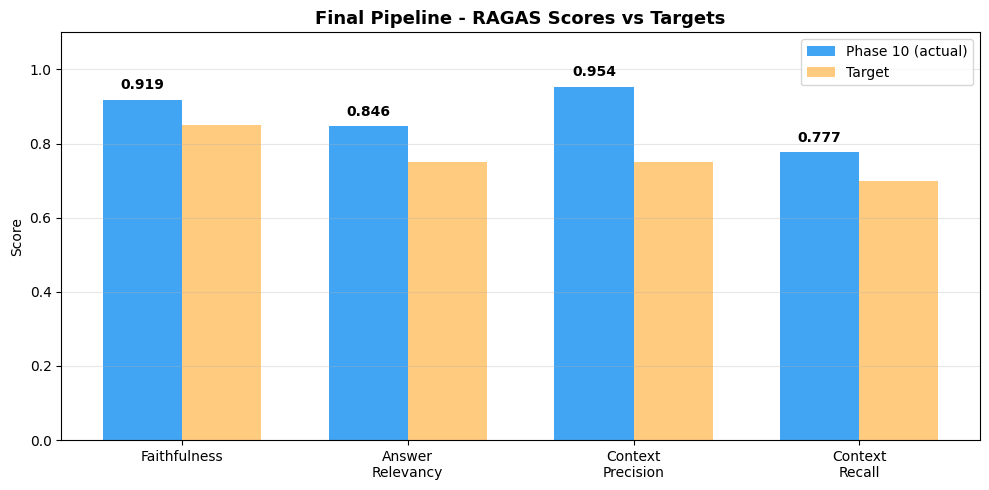

Chart saved.


In [15]:
# Bar chart: RAGAS scores vs targets
fig, ax = plt.subplots(figsize=(10, 5))

metric_labels = ["Faithfulness", "Answer\nRelevancy", "Context\nPrecision", "Context\nRecall"]
actual_vals = [scores.get(k, 0) for k in metric_cols]
target_vals = [targets.get(k, 0) for k in metric_cols]

x = np.arange(len(metric_labels))
width = 0.35

bars1 = ax.bar(x - width/2, actual_vals, width, label="Phase 10 (actual)", color="#2196F3", alpha=0.85)
bars2 = ax.bar(x + width/2, target_vals, width, label="Target", color="#FF9800", alpha=0.5)

ax.set_ylabel("Score")
ax.set_title("Final Pipeline - RAGAS Scores vs Targets", fontsize=13, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(metric_labels)
ax.set_ylim(0, 1.1)
ax.legend()
ax.grid(axis="y", alpha=0.3)

for bar, val in zip(bars1, actual_vals):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
            f"{val:.3f}", ha="center", va="bottom", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.savefig(RESULTS_DIR / "full_pipeline_scores.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved.")

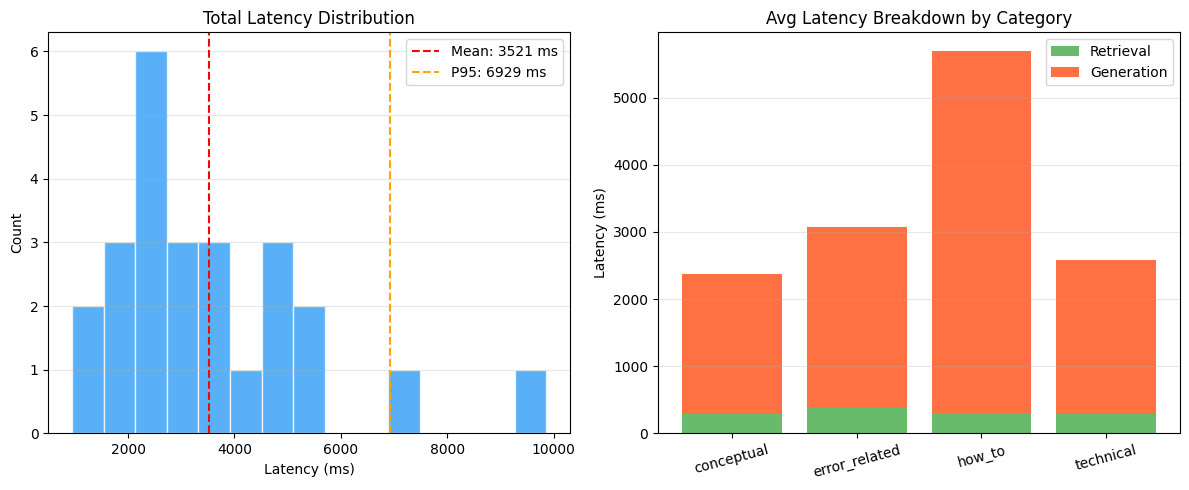

Chart saved.


In [16]:
# Latency breakdown: retrieval vs generation
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: histogram of total latency
axes[0].hist(latencies, bins=15, color="#2196F3", alpha=0.75, edgecolor="white")
axes[0].axvline(np.mean(latencies), color="red", linestyle="--", label=f"Mean: {np.mean(latencies):.0f} ms")
axes[0].axvline(np.percentile(latencies, 95), color="orange", linestyle="--", label=f"P95: {np.percentile(latencies, 95):.0f} ms")
axes[0].set_xlabel("Latency (ms)")
axes[0].set_ylabel("Count")
axes[0].set_title("Total Latency Distribution")
axes[0].legend()
axes[0].grid(axis="y", alpha=0.3)

# Right: stacked bar per category
cat_map = {q["id"]: q["category"] for q in ground_truths}
cat_ret = {}
cat_gen = {}
for r, q in zip(all_results, ground_truths):
    cat = q["category"]
    cat_ret.setdefault(cat, []).append(r.retrieval_ms)
    cat_gen.setdefault(cat, []).append(r.generation_ms)

categories = sorted(cat_ret.keys())
ret_means = [np.mean(cat_ret[c]) for c in categories]
gen_means = [np.mean(cat_gen[c]) for c in categories]

x = np.arange(len(categories))
axes[1].bar(x, ret_means, label="Retrieval", color="#4CAF50", alpha=0.85)
axes[1].bar(x, gen_means, bottom=ret_means, label="Generation", color="#FF5722", alpha=0.85)
axes[1].set_xticks(x)
axes[1].set_xticklabels(categories, rotation=15)
axes[1].set_ylabel("Latency (ms)")
axes[1].set_title("Avg Latency Breakdown by Category")
axes[1].legend()
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "full_pipeline_latency.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved.")

In [17]:
# Per-category RAGAS breakdown
df = ragas_df.copy()

# Find the question column name (RAGAS 0.4.x may use 'user_input' instead of 'question')
q_col = "user_input" if "user_input" in df.columns else "question"
cat_map = {q["question"]: q["category"] for q in ground_truths}
df["category"] = df[q_col].map(cat_map)

cat_df = df.groupby("category")[metric_cols].mean().round(4)
print("Per-category RAGAS scores:")
print(cat_df.to_string())

Per-category RAGAS scores:
               faithfulness  answer_relevancy  context_precision  context_recall
category                                                                        
conceptual            1.000            0.9164             0.9350          0.8333
error_related         1.000            0.8622             0.9130          0.9167
how_to                1.000            0.9455             0.9929          0.8867
technical             0.675            0.6437             0.9674          0.4333


## 9. Save Results

In [18]:
output = {
    "experiment": "phase10_full_pipeline",
    "config": {
        "llm": config["llm"]["model"],
        "embeddings": config["embeddings"]["model"],
        "retrieval_strategy": config["retrieval"]["strategy"],
        "reranking_enabled": config["reranking"]["enabled"],
        "reranking_model": config["reranking"]["model"],
    },
    "n_questions": len(ground_truths),
    "scores": {k: round(v, 4) for k, v in scores.items()},
    "avg_score": round(avg_score, 4),
    "latency": {
        "mean_ms": round(avg_latency, 1),
        "p50_ms": round(float(np.median(latencies)), 1),
        "p95_ms": round(float(np.percentile(latencies, 95)), 1),
        "mean_retrieval_ms": round(float(np.mean(retrieval_latencies)), 1),
        "mean_generation_ms": round(float(np.mean(generation_latencies)), 1),
    },
    "ragas_eval_elapsed_s": round(ragas_elapsed_s, 1),
    "targets": targets,
    "target_results": {
        k: "PASS" if scores.get(k, 0) >= v else "MISS"
        for k, v in targets.items()
    },
}

with open(RESULTS_PATH, "w", encoding="utf-8") as f:
    json.dump(output, f, indent=2, ensure_ascii=False)

print(f"Results saved -> {RESULTS_PATH}")

Results saved -> D:\Astyan\rag-exploration\results\full_pipeline.json


## 10. Cleanup

In [19]:
import chromadb

client = chromadb.PersistentClient(path=str(PERSIST_DIR))
existing_collections = [c.name for c in client.list_collections()]

if COLLECTION_NAME in existing_collections:
    client.delete_collection(COLLECTION_NAME)
    print(f"Deleted collection '{COLLECTION_NAME}'")
else:
    print(f"Collection '{COLLECTION_NAME}' not found (already deleted?)")

print("Cleanup complete.")

Deleted collection 'full_pipeline_mxbai'
Cleanup complete.


## 11. Conclusion

### Final Pipeline Configuration

| Component | Value |
|-----------|-------|
| Chunking | Recursive, 1000/200 |
| Embeddings | mxbai-embed-large |
| Retrieval | Hybrid BM25+Dense (0.5/0.5), 20 candidates each |
| Reranking | Cross-encoder ms-marco-MiniLM, top-5 |
| LLM | Mistral 7B, temperature 0.0 |

### RAGAS Scores (25 questions) - All targets met

| Metric | Score | Target | Status |
|--------|-------|--------|--------|
| Faithfulness | 0.9188 | 0.85 | PASS |
| Answer Relevancy | 0.8461 | 0.75 | PASS |
| Context Precision | 0.9537 | 0.75 | PASS |
| Context Recall | 0.7773 | 0.70 | PASS |
| **Average** | **0.8739** | | |

### Latency

| Stat | Value | Target |
|------|-------|--------|
| Mean | 3521 ms | < 5000 ms |
| P95 | 6929 ms | < 10000 ms |

### Per-category analysis

Three categories score excellent (faithfulness = 1.0):
- **how_to**: best overall (relevancy 0.95, recall 0.89)
- **error_related**: strong recall (0.92) - the corpus covers common errors well
- **conceptual**: solid across all metrics (recall 0.83)

**`technical` is the weak spot** (faithfulness 0.68, relevancy 0.64, recall 0.43). Mistral hallucinates on precise technical questions (class parameters, function signatures), and the corpus lacks detailed API reference content. This is a corpus limitation, not a pipeline limitation.

### Stability vs Phase 9

Phase 10 (25 questions) closely matches Phase 9 hybrid_reranked (12 questions): avg 0.874 vs 0.871. The pipeline results are stable and reproducible across sample sizes.

### Key Takeaways

1. **Cross-encoder reranking is the most impactful component** - consistently improves faithfulness and relevancy by pushing the most relevant chunks to the top of the context.
2. **Query translation, routing, and advanced patterns were disabled** because Mistral 7B is too weak for the meta-reasoning they require. A stronger LLM would likely benefit from these techniques.
3. **The bottleneck is generation** (~2-4s per question), not retrieval+reranking (~500ms). Faster inference (quantization, GPU upgrade, or a smaller model) would have the biggest latency impact.
4. **Technical questions need better corpus coverage** - enriching the API reference content or using finer-grained chunking for reference pages would improve the weakest category.

### Next Step

Phase 11 will wrap this pipeline in a Chainlit chat interface for interactive use.